<a href="https://colab.research.google.com/github/DonovanBilanoski/DonovanBilanoski/blob/main/Final_Exam_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing all required libraries for data processing, model training, evaluation, and visualization.
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
import xgboost as xgb

In [ ]:
# Loading the dataset from an Excel file containing patient information for heart disease prediction.
file_path = "Final Exam Project.xlsx"
xls = pd.ExcelFile(file_path)
df_raw = pd.read_excel(xls, sheet_name='heart (1)')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Displaying the first few rows of the raw dataset to understand its structure and contents.
print("Raw Dataset:")
display(df_raw.head())

Raw Dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# Creating a copy of the original dataset for processing, keeping the raw data intact for reference.
df = df_raw.copy()

In [ ]:
# Defining the target variable ('HeartDisease') which we are trying to predict (binary classification: 0 or 1).
target_col = 'HeartDisease'  # Replace with the actual target column name
y = df[target_col]
df = df.drop(columns=[target_col])

In [ ]:
# Encoding categorical features using OneHotEncoder to convert them into numeric form, required by machine learning algorithms.
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
encoder = OneHotEncoder(drop='first', sparse_output=False)
categorical_transformed = encoder.fit_transform(df[categorical_cols])
categorical_df = pd.DataFrame(categorical_transformed, columns=encoder.get_feature_names_out(categorical_cols))

In [ ]:
# Standardizing numerical features to have mean 0 and standard deviation 1 for better model convergence and comparability.
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [ ]:
# Normalizing the numerical features between 0 and 1 using MinMaxScaler to ensure all features are on the same scale.
normalizer = MinMaxScaler()
df[numerical_cols] = normalizer.fit_transform(df[numerical_cols])

In [ ]:
# Dropping original categorical columns and combining the encoded categorical data with the numerical feature set.
df = df.drop(columns=categorical_cols)
df = pd.concat([df, categorical_df], axis=1)

In [ ]:
# Splitting the dataset into training, validation, and test sets (70%, 10%, 20%) to evaluate model performance on unseen data.
X_train, X_temp, y_train, y_temp = train_test_split(df, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42)

In [ ]:
# Initializing a dictionary of classification models to train, covering a wide range of algorithm types (linear, tree-based, distance-based, etc.).
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True, random_state=42)
}

In [ ]:
# Training each model on the training dataset and storing the fitted models in a dictionary.
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:54:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
# Defining a reusable evaluation function to print accuracy, precision, recall, F1-score, and ROC-AUC (if applicable).
def evaluate_model(name, model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else None
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y, y_pred))
    print("Classification Report:\n", classification_report(y, y_pred))
    if y_prob is not None:
        print("ROC-AUC:", roc_auc_score(y, y_prob))
    print()

In [ ]:
# Evaluating all trained models on the validation set to identify which ones perform best before testing.
print("=== Model Evaluation on Validation Set ===")
for name, model in trained_models.items():
    evaluate_model(name, model, X_val, y_val)

=== Model Evaluation on Validation Set ===
--- Logistic Regression ---
Accuracy: 0.8586956521739131
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.87      0.80        30
           1       0.93      0.85      0.89        62

    accuracy                           0.86        92
   macro avg       0.84      0.86      0.85        92
weighted avg       0.87      0.86      0.86        92

ROC-AUC: 0.9252688172043011

--- Decision Tree ---
Accuracy: 0.7608695652173914
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.80      0.69        30
           1       0.88      0.74      0.81        62

    accuracy                           0.76        92
   macro avg       0.74      0.77      0.75        92
weighted avg       0.79      0.76      0.77        92

ROC-AUC: 0.7709677419354839

--- Random Forest ---
Accuracy: 0.8369565217391305
Classification Report:
               

In [ ]:
# Creating a soft-voting ensemble using the three best-performing models based on validation scores.
voting_clf = VotingClassifier(
    estimators=[
        ('rf', trained_models['Random Forest']),
        ('xgb', trained_models['XGBoost']),
        ('lr', trained_models['Logistic Regression'])
    ],
    voting='soft'
)
voting_clf.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:54:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importanc...
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                             ('lr', LogisticRegression(max_iter=1000))],
                 voting='soft')

In [ ]:
# Evaluating the voting ensemble on both validation and test datasets to check for improved performance.
print("=== Voting Classifier on Validation Set ===")
evaluate_model("Voting Classifier", voting_clf, X_val, y_val)

print("=== Voting Classifier on Test Set ===")
evaluate_model("Voting Classifier", voting_clf, X_test, y_test)

# Creating a Bayesian-style ensemble by averaging probabilities of the top 3 models to estimate final predictions.
def bayesian_ensemble(models, X):
    probs = np.mean([model.predict_proba(X)[:, 1] for model in models if hasattr(model, "predict_proba")], axis=0)
    return (probs > 0.5).astype(int), probs

=== Voting Classifier on Validation Set ===
--- Voting Classifier ---
Accuracy: 0.8586956521739131
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.87      0.80        30
           1       0.93      0.85      0.89        62

    accuracy                           0.86        92
   macro avg       0.84      0.86      0.85        92
weighted avg       0.87      0.86      0.86        92

ROC-AUC: 0.9327956989247312

=== Voting Classifier on Test Set ===
--- Voting Classifier ---
Accuracy: 0.8967391304347826
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88        82
           1       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184

ROC-AUC: 0.9461979913916786



In [ ]:
# Use top 3 models
ensemble_models = [trained_models['Random Forest'], trained_models['XGBoost'], trained_models['Logistic Regression']]
y_val_bayes, y_val_bayes_prob = bayesian_ensemble(ensemble_models, X_val)
y_test_bayes, y_test_bayes_prob = bayesian_ensemble(ensemble_models, X_test)

=== Bayesian Ensemble on Validation Set ===
Accuracy: 0.8586956521739131
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.87      0.80        30
           1       0.93      0.85      0.89        62

    accuracy                           0.86        92
   macro avg       0.84      0.86      0.85        92
weighted avg       0.87      0.86      0.86        92

ROC-AUC: 0.9327956989247312
=== Bayesian Ensemble on Test Set ===
Accuracy: 0.8967391304347826
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88        82
           1       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184

ROC-AUC: 0.9461979913916786


<Figure size 600x400 with 0 Axes>

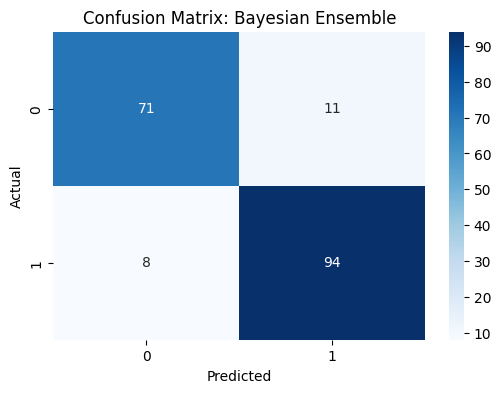

In [ ]:
# Applying the Bayesian ensemble on validation and test sets for comparison.
print("=== Bayesian Ensemble on Validation Set ===")
print("Accuracy:", accuracy_score(y_val, y_val_bayes))
print("Classification Report:\n", classification_report(y_val, y_val_bayes))
print("ROC-AUC:", roc_auc_score(y_val, y_val_bayes_prob))

print("=== Bayesian Ensemble on Test Set ===")
print("Accuracy:", accuracy_score(y_test, y_test_bayes))
print("Classification Report:\n", classification_report(y_test, y_test_bayes))
print("ROC-AUC:", roc_auc_score(y_test, y_test_bayes_prob))

# Plotting a confusion matrix to visually inspect how well the Bayesian ensemble predicted true vs. false labels.
plt.figure(figsize=(6, 4))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_test_bayes), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Bayesian Ensemble")
plt.show()

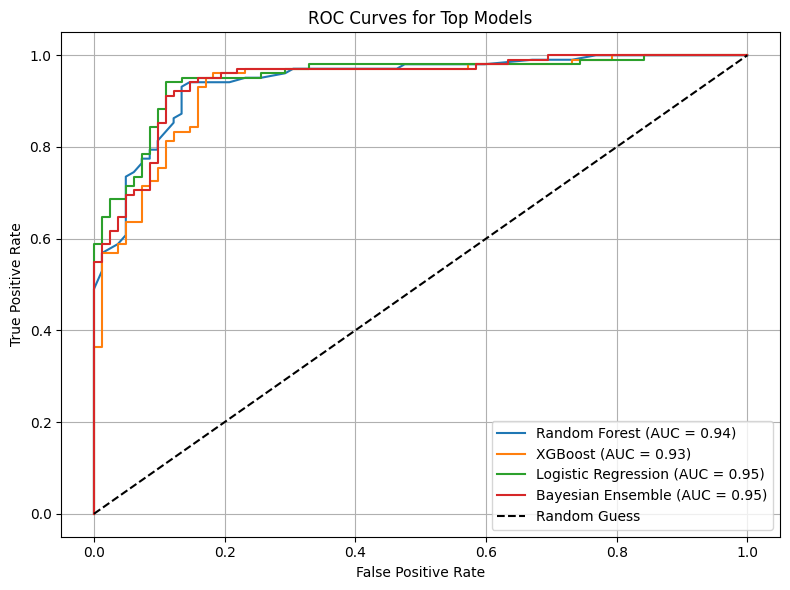

In [ ]:
# Importing the function to compute the ROC curve points (FPR, TPR)
from sklearn.metrics import roc_curve

# We want to visually compare the ability of our top models to distinguish between classes.
# We'll do this by plotting their ROC curves and calculating their AUC (Area Under Curve) scores.
# The ROC curve shows the tradeoff between the true positive rate and false positive rate at different thresholds.

# Selecting models to include in the ROC plot.
# These are our top-performing individual models, plus our custom Bayesian Ensemble.
models_to_plot = {
    'Random Forest': trained_models['Random Forest'],
    'XGBoost': trained_models['XGBoost'],
    'Logistic Regression': trained_models['Logistic Regression'],
    'Bayesian Ensemble': None  # The ensemble will be handled separately because it's not a built-in sklearn model
}

# Initializing the plot window with a specific size
plt.figure(figsize=(8, 6))

# Looping through each model to generate its ROC curve
for name, model in models_to_plot.items():
    if model is not None:
        # For standard models, get the predicted probabilities for the positive class (label 1)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # For the Bayesian Ensemble, manually average the predicted probabilities from the top 3 models
        # This gives a smoother and potentially more accurate prediction
        _, y_prob = bayesian_ensemble([
            trained_models['Random Forest'],
            trained_models['XGBoost'],
            trained_models['Logistic Regression']
        ], X_test)

    # Compute the False Positive Rate (FPR) and True Positive Rate (TPR) to plot the ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Calculate the AUC score, which summarizes the overall performance of the model
    # AUC closer to 1.0 indicates better performance
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot the ROC curve with a label showing the AUC
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

# Plot a dashed diagonal line as a baseline representing random guessing (AUC = 0.50)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Labeling the axes for interpretability
plt.xlabel('False Positive Rate')   # X-axis: probability of incorrectly classifying a negative as positive
plt.ylabel('True Positive Rate')    # Y-axis: probability of correctly classifying a positive as positive

# Giving the plot a title to clarify what it represents
plt.title('ROC Curves for Top Models')

# Adding a legend to identify each model's curve
plt.legend(loc='lower right')

# Adding gridlines and tightening layout for cleaner display
plt.grid(True)
plt.tight_layout()

# Display the ROC plot
plt.show()

In [ ]:
# Saving the final processed train, validation, and test feature sets to CSV files for potential reuse or deployment.
X_train.to_csv("train_heart_failure_data.csv", index=False)
X_val.to_csv("val_heart_failure_data.csv", index=False)
X_test.to_csv("test_heart_failure_data.csv", index=False)